# Determining Drag Area Coefficient from Cruising Tests

**Author:** Ryan Huang

**Date:** 2026-05-16

**Relevant Links:**
- This analysis reuses some code from the [2025 Brightside Cruise Test](https://github.com/UBC-Solar/data_analysis/blob/main/v3/motor_analysis/motor_testing_april_6.ipynb)

## Imports

Import any packages or dependencies for this project.
Uncomment or delete these lines as needed, and add other dependencies

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import dill
from data_tools.collections import TimeSeries
from data_tools.query import DBClient
from datetime import datetime
from pathlib import Path
from scipy import stats


## Data Acquisition

Obtain the data relevant to this analysis. Load data from saved files, or query it directly.

In [10]:
LOAD_FROM_FILE = False 
DATA_DIR = Path("data")

if LOAD_FROM_FILE:
    
    speed_file = DATA_DIR / "cruise_motor_speeds.bin"
    current_file = DATA_DIR / "cruise_pack_currents.bin"
    brake_file = DATA_DIR / "cruise_brake_presseds.bin"
    with open(speed_file, "rb") as f:
        cruise_speeds: list[TimeSeries] = dill.load(f)
    with open(current_file, "rb") as f:
        cruise_pack_currents: list[TimeSeries] = dill.load(f)
    with open(brake_file, "rb") as f:
        cruise_brake_presseds: list[TimeSeries] = dill.load(f)

else:
    client = DBClient()
    PACK_CURRENT_THRESHOLD = 0.10682  # pack current never reads 0; its lowest value is this constant (constant is rounded up here)
    start_times = [datetime.fromisoformat("2026-04-02T20:02:25Z"),
                   datetime.fromisoformat("2026-04-02T20:07:05Z"),
                   datetime.fromisoformat("2026-04-02T20:25:57Z"),
                   datetime.fromisoformat("2026-04-02T20:35:34Z"),]
    
    stop_times = [datetime.fromisoformat("2026-04-02T20:03:02Z"),
                  datetime.fromisoformat("2026-04-02T20:07:31Z"),
                  datetime.fromisoformat("2026-04-02T20:26:38Z"),
                  datetime.fromisoformat("2026-04-02T20:36:12Z"),]
    
    cruise_speeds: list[TimeSeries] = []
    cruise_pack_currents: list[TimeSeries] = []
    cruise_brake_presseds: list[TimeSeries] = []

    for start, stop in zip(start_times, stop_times):
        motor_rotating_speed: TimeSeries = client.query_time_series(start=start, stop=stop, field="MotorRotatingSpeed", units="km/h")
        pack_current: TimeSeries = client.query_time_series(start=start, stop=stop, field="PackCurrent", units="A")
        brake_pressed: TimeSeries = client.query_time_series(start=start, stop=stop, field="BrakePressed")

        motor_rotating_speed, pack_current, brake_pressed = TimeSeries.align( # different sampling rates for each data
            motor_rotating_speed, pack_current, brake_pressed
        ) 

        cruise_speeds.append(motor_rotating_speed)
        cruise_pack_currents.append(pack_current)
        cruise_brake_presseds.append(brake_pressed)

    # with open(DATA_DIR / "cruise_motor_speeds.bin", 'wb') as f:
    #     dill.dump(cruise_motor_speeds, f)
    # with open(DATA_DIR / "cruise_pack_currents.bin", 'wb') as f:
    #     dill.dump(cruise_pack_currents, f)
    # with open(DATA_DIR / "cruise_brake_presseds.bin", 'wb') as f:
    #     dill.dump(cruise_brake_presseds, f)

## Analysis

Compute the desired results and present them. Take advantage of Markdown cells to guide the reader through your derivation process.

### Plotting the Data

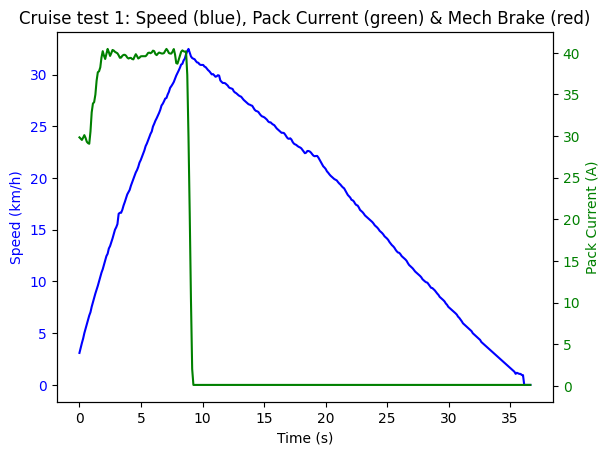

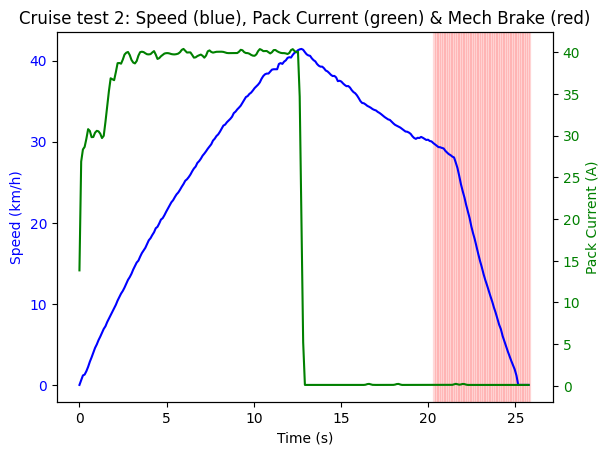

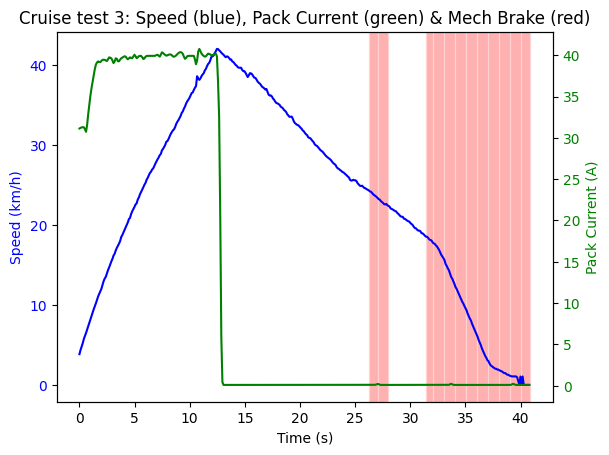

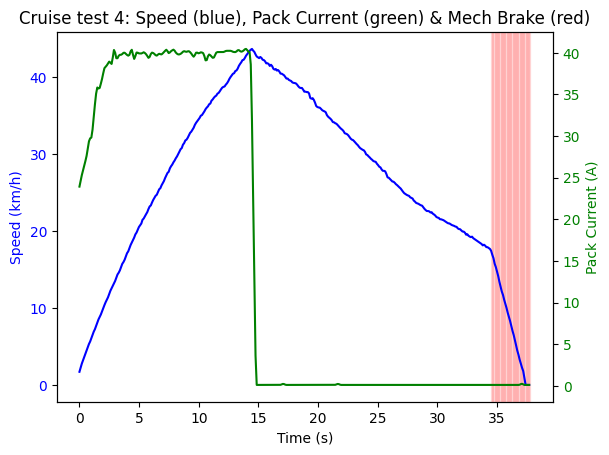

In [11]:
for i, (speed, current, brake) in enumerate(zip(cruise_speeds, cruise_pack_currents, cruise_brake_presseds)):
    fig, ax1 = plt.subplots()
    t_axis = speed.x_axis
    period = speed.period

    # Plot Speed (km/h) on the left y-axis
    ax1.plot(t_axis, speed, color='blue')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Speed (km/h)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Create a secondary y-axis for pack current (A)
    ax2 = ax1.twinx()
    ax2.plot(t_axis, current, color='green')
    ax2.set_ylabel('Pack Current (A)', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Change background color based on brake (1 or 0)
    for j, value in enumerate(brake):
        if value == 1:
            ax1.axvspan(t_axis[j], t_axis[j]+period, color='red', alpha=0.1)  # Highlight background when brake is pressed
    
    plt.title(f"Cruise test {i+1}: Speed (blue), Pack Current (green) & Mech Brake (red)")
    plt.show()


### Analysis

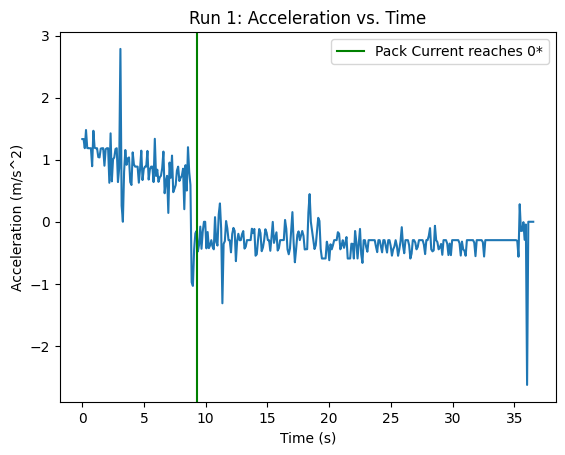

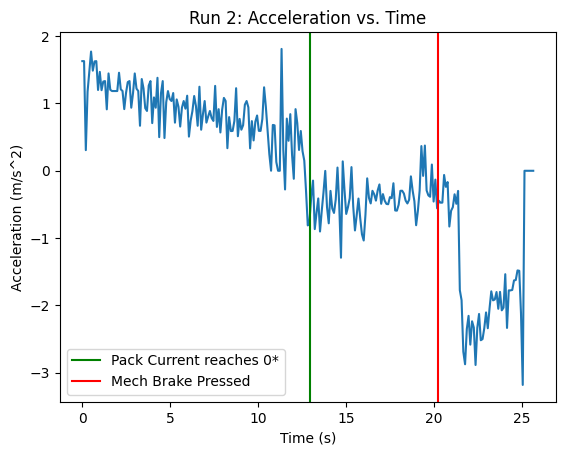

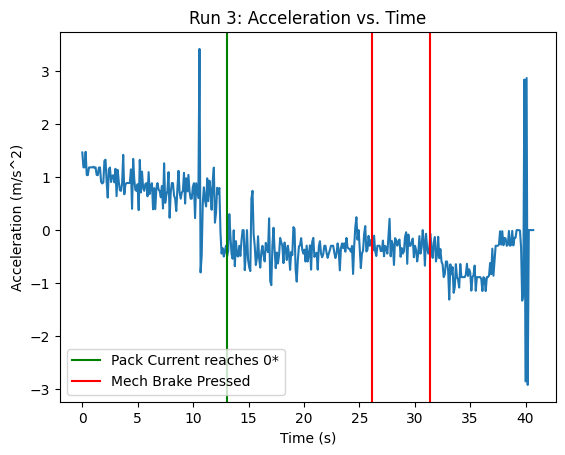

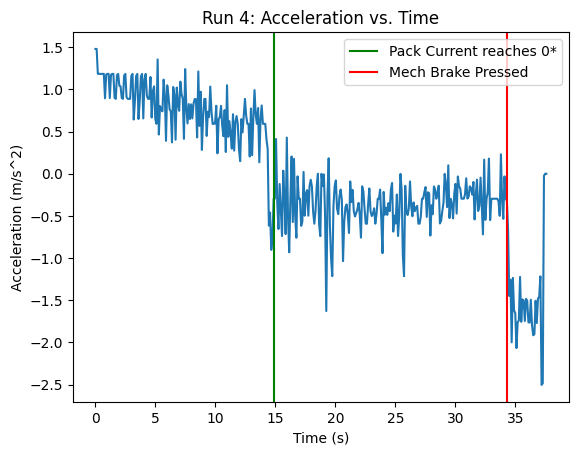

In [12]:
KMH_PER_MPS = 3.6

for i, (speed, current, brake) in enumerate(zip(cruise_speeds, cruise_pack_currents, cruise_brake_presseds)):
    period = speed.period
    t_axis = speed.x_axis

    acceleration = (np.diff(np.asarray(speed)) / period) / KMH_PER_MPS  # np.asarray(speed) turns TimeSeries into a basic np.ndarray, guaranteeing these operations work
    plt.plot(t_axis[:-1], acceleration)  # np.diff results in a 1 item shorter array

    cruise_start_time = np.where(current <= PACK_CURRENT_THRESHOLD)[0][0] * period
    plt.axvline(cruise_start_time, c="green", label = "Pack Current reaches 0*") # star because current technically reaches PACK_CURRENT_THRESHOLD. I am assuming it is a sensor issue?

    brake_indices = np.where(brake > 0)[0]
    if brake_indices.size > 0:
        # identifying brake "groups" (i.e. each time the brake was pressed down) and plottng each group as a separate line. 
        gap_indices = np.where(np.diff(brake_indices) > 1)[0]
        brake_start_indices = np.concatenate([[brake_indices[0]], brake_indices[gap_indices + 1]])

        for j, brake_start_index in enumerate(brake_start_indices):
            brake_time = brake_start_index * period
            label = "Mech Brake Pressed" if j == 0 else "_nolegend_"
            plt.axvline(brake_time, c="red", label = label)
    
    plt.title(f"Run {i+1}: Acceleration vs. Time")
    plt.ylabel("Acceleration (m/s^2)")
    plt.xlabel("Time (s)")
    plt.legend()
    plt.show()


#### Extracting cruise test windows

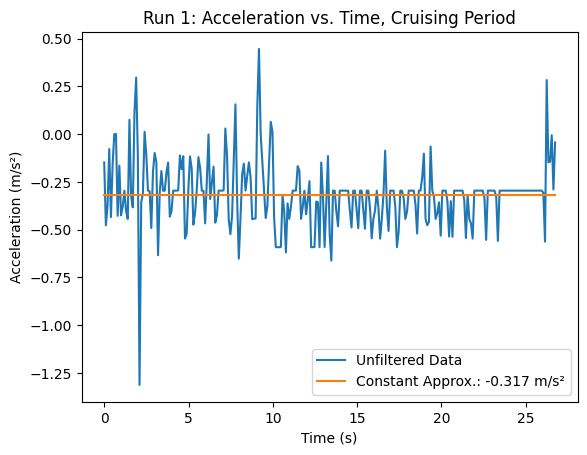

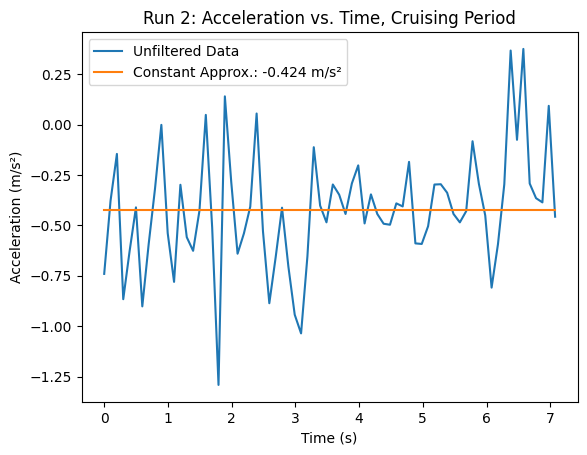

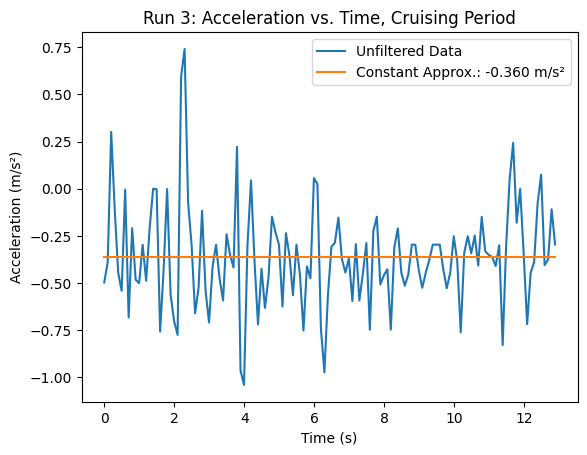

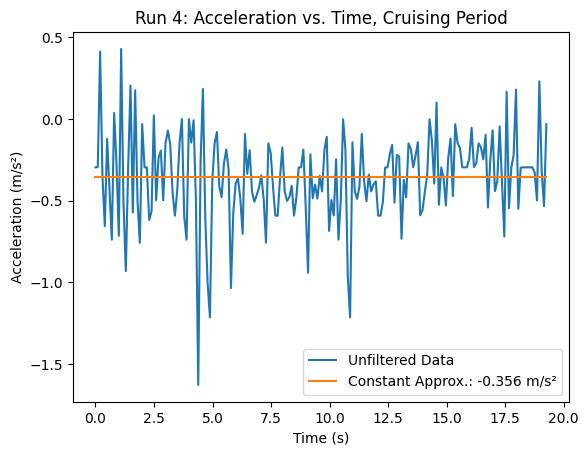

In [13]:
cruise_window_speeds: list[TimeSeries] = []

for speed, current, brake in zip(cruise_speeds, cruise_pack_currents, cruise_brake_presseds):
    cruise_start_index = np.where(current <= PACK_CURRENT_THRESHOLD)[0][0]

    brake_indices = np.where(brake > 0)[0]
    if brake_indices.size == 0:
        zero_speed_indices = np.where(speed == 0)[0]
        cruise_end_index = zero_speed_indices[0]        # for runs where brake wasn't pressed end the cruise when speed == 0
    else:    
        cruise_end_index = brake_indices[0]

    cruise_start_time = current.datetime_x_axis[cruise_start_index]
    cruise_end_time = brake.datetime_x_axis [cruise_end_index]

    cruise_window_speed: TimeSeries = speed.slice(cruise_start_time, cruise_end_time)
    cruise_window_speed.meta = speed.meta

    cruise_window_speeds.append(cruise_window_speed)

for i, speed in enumerate(cruise_window_speeds):
    period = speed.period
    t_axis = speed.x_axis

    acceleration = (np.diff(np.asarray(speed)) / period) / KMH_PER_MPS
    mean_accel = np.mean(acceleration)
    constant_approx = np.ones(len(acceleration)) * mean_accel

    plt.plot(t_axis[:-1], acceleration, label="Unfiltered Data")
    plt.plot(t_axis[:-1], constant_approx, label=f"Constant Approx.: {mean_accel:.3f} m/s²")
    plt.title(f"Run {i+1}: Acceleration vs. Time, Cruising Period")
    plt.ylabel("Acceleration (m/s²)")
    plt.xlabel("Time (s)")
    plt.legend()
    plt.show() 

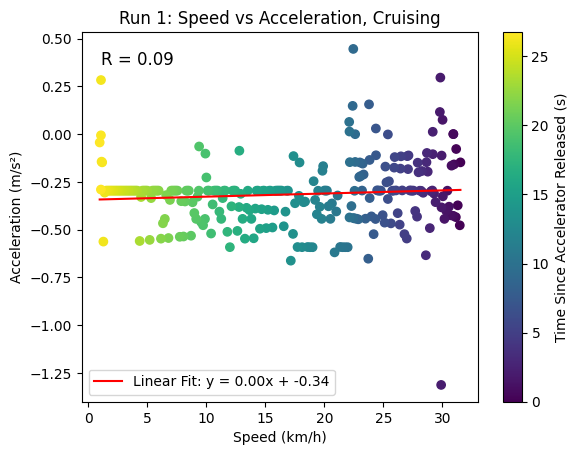

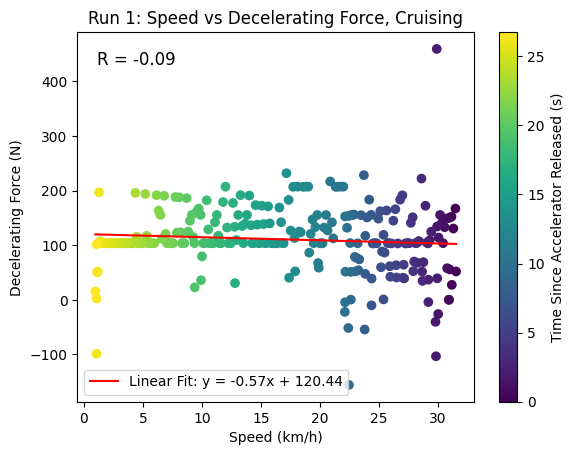

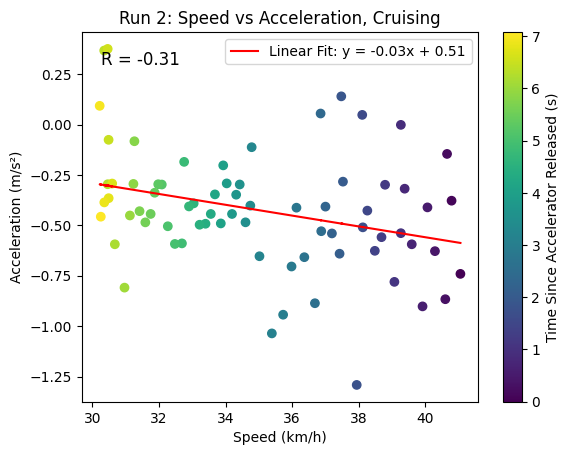

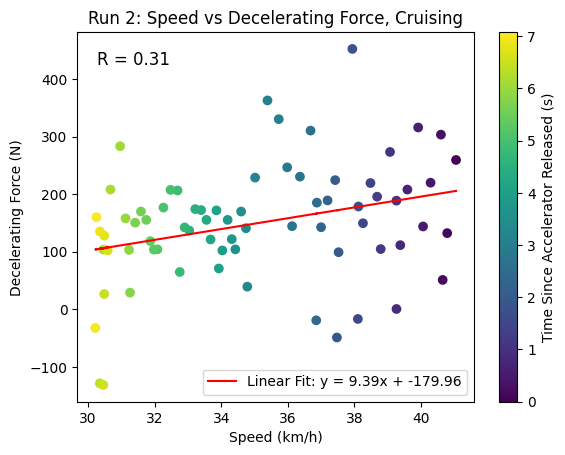

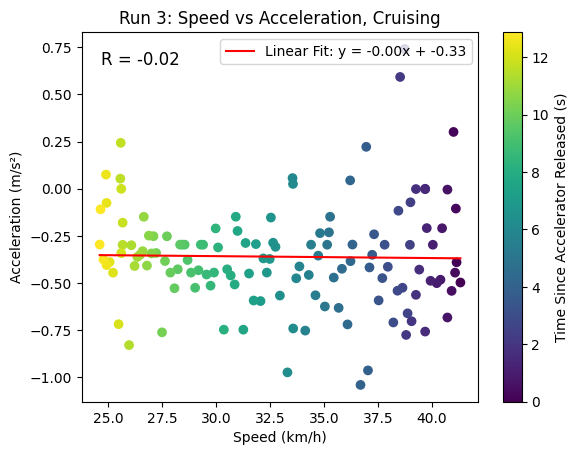

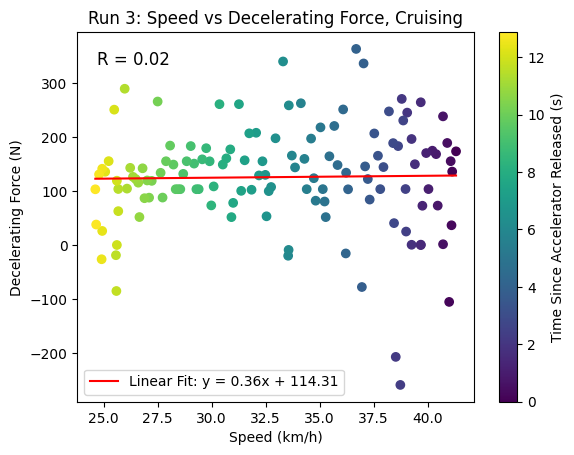

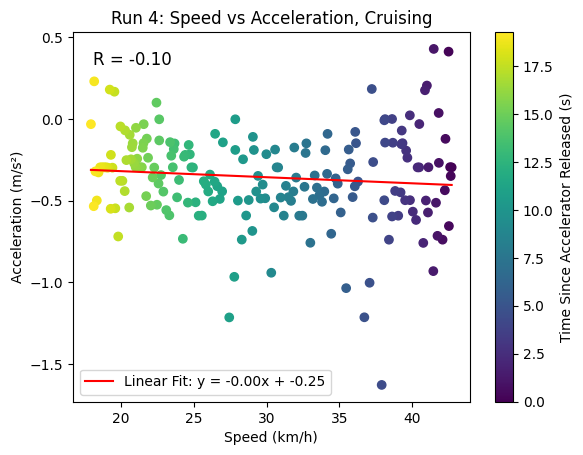

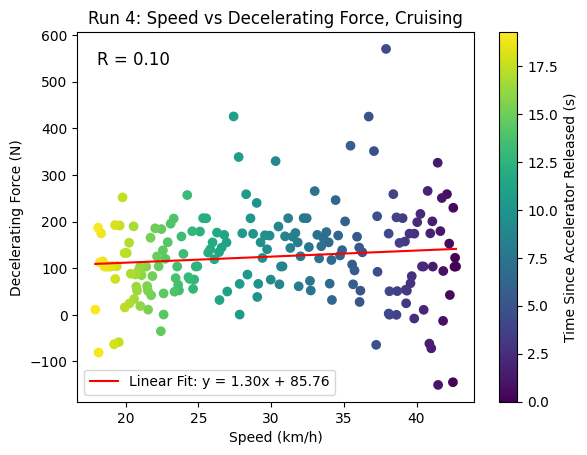

In [19]:
BRIGHTSIDE_MASS_KG = 350 # value taken from the 2025 analysis
for i, speed in enumerate(cruise_window_speeds):
    period = speed.period
    t_axis = speed.x_axis

    acceleration = (np.diff(np.asarray(speed)) / period) / KMH_PER_MPS
    force = BRIGHTSIDE_MASS_KG * acceleration * -1 # F = ma, and flip sign to get slowing force
    speed_without_last = speed[:-1]
    time_since_cruising = t_axis[:-1] - t_axis[0]

    for y_data, y_label, title in [
        (acceleration, "Acceleration (m/s²)", f"Run {i+1}: Speed vs Acceleration, Cruising"),
        (force, "Decelerating Force (N)", f"Run {i+1}: Speed vs Decelerating Force, Cruising"),
    ]:  
    
        slope, intercept, r_value, _, _ = stats.linregress(speed_without_last, y_data)
        fit_line: np.ndarray = slope * np.asarray(speed_without_last) + intercept

        plt.scatter(speed_without_last, y_data, c=time_since_cruising)
        plt.title(title)
        plt.xlabel("Speed (km/h)")
        plt.ylabel(y_label)
        plt.colorbar(label="Time Since Accelerator Released (s)")

        plt.text(0.05, 0.95, f"R = {r_value:.2f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

        plt.plot(speed_without_last, fit_line, color='red', label=f"Linear Fit: y = {slope:.2f}x + {intercept:.2f}")
        plt.legend()
        plt.show()
